# 3/3 (v6) — Policy training driven purely by the time2success model

Follows `2_train_validate_v6.ipynb`. That notebook showed the v6 model ranks
states correctly on the fixed scene (mean rho 0.998). This notebook asks the
next question: can that model **by itself**, as the only reward signal,
teach SAC the peg-insertion motion?

Three constraints, all deliberate, all requested:

1. **No random seed anywhere.** Same `fixed_task.pkl` from notebook 1, for
   both the training envs and the eval env. Nothing about the scene varies
   across the whole run.
2. **Reward = the time difference.** Not the discounted potential-based
   shaping (`gamma*phi(s') - phi(s)`) from the older exploratory notebook —
   just the literal difference in the model's predicted steps-remaining
   between consecutive states: `predict_t2s(s_t) - predict_t2s(s_{t+1})`.
   Positive when the state moved closer to predicted success. Simpler and
   more direct, at the cost of the theoretical policy-invariance guarantee
   potential-based shaping has.
3. **Peg location removed from the policy's observation.** The scene never
   changes here, so the peg's raw coordinates are a constant — they carry no
   information for a state-conditioned policy and this ablation is
   specifically about whether proprioception plus the reward signal is
   enough, without letting the policy just read off peg position directly.
   The time2success model still sees the *full* observation (it needs peg
   position — that's in its 49-dim feature vector) — only the policy's view
   is reduced.

**Caveat worth watching for:** the v6 model was trained only on
near-optimal successful trajectories. Early in training, a barely-trained
policy will visit states far outside that distribution, where the model's
predictions are extrapolation and may be noisy or misleading. If training
looks unstable, that's the first thing to suspect — not a bug.

Run top to bottom. Section 6 is a smoke test — check it before the full run.

## 1. Setup — feature builder + the trained v6 time2success model

In [1]:
import numpy as np
import torch
import torch.nn as nn
import gymnasium as gym
import metaworld
import os, json, pickle, glob, time
import imageio
from stable_baselines3 import SAC
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor
from stable_baselines3.common.callbacks import BaseCallback
import matplotlib.pyplot as plt

In [2]:
# ============================================================
# SHARED FEATURE BUILDER — must match 1_collect_v6.ipynb / 2_train_validate_v6.ipynb.
# This is what the TIME2SUCCESS MODEL sees. It is NOT what the policy sees —
# the policy's observation is reduced further below (peg position removed).
# ============================================================
HAND_POS_IDX = [0, 1, 2]
GRIPPER_IDX  = 3
PEG_POS_IDX  = [4, 5, 6]
GOAL_POS_IDX = [36, 37, 38]
GRIPPER_CLOSED_THRESHOLD = 0.6
FEATURE_DIM = 49

def build_features(obs):
    obs = np.asarray(obs, dtype=np.float32)
    hand = obs[HAND_POS_IDX]
    peg  = obs[PEG_POS_IDX]
    goal = obs[GOAL_POS_IDX]
    gripper = obs[GRIPPER_IDX]

    hand_to_peg_vec = peg - hand
    peg_to_goal_vec = goal - peg
    hand_to_peg = np.linalg.norm(hand_to_peg_vec)
    peg_to_goal = np.linalg.norm(peg_to_goal_vec)
    holding = float(gripper < GRIPPER_CLOSED_THRESHOLD and hand_to_peg < 0.06)

    return np.concatenate([
        obs,
        hand_to_peg_vec,
        peg_to_goal_vec,
        [hand_to_peg, peg_to_goal, gripper, holding],
    ]).astype(np.float32)

In [3]:
TASK_NAME = "peg-insert-side-v3"
SUCCESS_KEY = "success"

def make_env(seed=0, render_mode=None):
    return gym.make("Meta-World/MT1", env_name=TASK_NAME, seed=seed, render_mode=render_mode)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


In [4]:
class Time2SuccessModel(nn.Module):
    def __init__(self, obs_dim, hidden=256, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

T2S_MODEL_DIR = "./checkpoints/time2success_v6"
norm = np.load(os.path.join(T2S_MODEL_DIR, "normalization.npz"))
X_MEAN, X_STD = norm["X_mean"], norm["X_std"]
Y_MEAN, Y_STD = norm["y_mean"].item(), norm["y_std"].item()

t2s_model = Time2SuccessModel(obs_dim=FEATURE_DIM).to(device)
t2s_model.load_state_dict(torch.load(os.path.join(T2S_MODEL_DIR, "model.pt")))
t2s_model.eval()
for p in t2s_model.parameters():
    p.requires_grad_(False)   # frozen — never trained during policy learning

# Clip predictions to the range the model actually saw in training (dataset_summary.json:
# anchor_frame 66-100) so an early, off-distribution policy can't produce a wild
# extrapolated value that blows up the reward.
PRED_CLIP_MAX = 150.0

@torch.no_grad()
def predict_t2s(full_obs):
    """full_obs is the RAW 39-dim env observation (peg position included) —
    always the pre-stripped observation, never what the policy sees."""
    feat = build_features(full_obs)
    x = torch.tensor((feat - X_MEAN) / X_STD, dtype=torch.float32).unsqueeze(0).to(device)
    pred_norm = t2s_model(x).item()
    pred = pred_norm * Y_STD + Y_MEAN
    return float(np.clip(pred, 0.0, PRED_CLIP_MAX))

print(f"loaded time2success model from {T2S_MODEL_DIR}, prediction clipped to [0, {PRED_CLIP_MAX}]")

loaded time2success model from ./checkpoints/time2success_v6, prediction clipped to [0, 150.0]


## 2. The fixed scene — same task as notebooks 1 and 2

In [5]:
FIXED_TASK_PATH = "./data/state_space_datasetV6/fixed_task.pkl"
assert os.path.exists(FIXED_TASK_PATH), "run 1_collect_v6.ipynb first"

def find_wrapper(env, attr_name):
    w = env
    while not hasattr(w, attr_name):
        if not hasattr(w, "env"):
            raise AttributeError(f"no wrapper in the chain exposes {attr_name!r}")
        w = w.env
    return w

def make_fixed_scene_env(render_mode=None):
    env = make_env(seed=0, render_mode=render_mode)
    find_wrapper(env, "tasks").toggle_sample_tasks_on_reset(False)
    with open(FIXED_TASK_PATH, "rb") as f:
        fixed_task = pickle.load(f)
    env.unwrapped.set_task(fixed_task)
    return env

## 3. The two wrappers

Order matters: the reward wrapper sits *closer to the base env* than the
observation-stripping wrapper, so it always computes the time2success
potential from the full, un-stripped observation — even though, by the time
that observation reaches the policy, the peg columns are gone.

In [6]:
class Time2SuccessTimeDiffRewardWrapper(gym.Wrapper):
    """reward_t = predict_t2s(s_t) - predict_t2s(s_{t+1}) — literally the
    change in predicted steps-remaining, no discounting. Replaces the
    environment's own reward entirely."""
    def __init__(self, env):
        super().__init__(env)
        self._last_obs = None

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self._last_obs = obs
        return obs, info

    def step(self, action):
        obs, _env_reward, terminated, truncated, info = self.env.step(action)
        pred_before = predict_t2s(self._last_obs)
        pred_after = predict_t2s(obs)
        reward = pred_before - pred_after
        self._last_obs = obs
        return obs, reward, terminated, truncated, info


class RemovePegPositionWrapper(gym.ObservationWrapper):
    """Drops the peg-position columns (raw obs indices 4:7) from what the
    policy observes. The scene is fixed, so those columns are a constant —
    removing them costs no real information here, and forces the policy to
    act from proprioception + the reward signal instead of reading peg
    position directly."""
    def __init__(self, env):
        super().__init__(env)
        obs_dim = env.observation_space.shape[0]
        self._keep_idx = np.array([i for i in range(obs_dim) if i not in PEG_POS_IDX])
        self.observation_space = gym.spaces.Box(
            low=-np.inf, high=np.inf, shape=(len(self._keep_idx),), dtype=np.float32)

    def observation(self, obs):
        return obs[self._keep_idx].astype(np.float32)


def make_policy_train_env():
    env = make_fixed_scene_env()
    env = Time2SuccessTimeDiffRewardWrapper(env)
    env = RemovePegPositionWrapper(env)
    return env

def make_policy_eval_env():
    """Raw success flag, no reward shaping — and terminate on success so
    eval rollouts don't run the full 500 steps once the policy can solve it."""
    env = make_fixed_scene_env()
    find_wrapper(env, "toggle_terminate_on_success").toggle_terminate_on_success(True)
    env = RemovePegPositionWrapper(env)
    return env

## 4. Smoke-check the wrappers before building the vec env

In [7]:
_env = make_policy_train_env()
_obs, _ = _env.reset()
print(f"policy observation shape: {_obs.shape} (expect (36,) = 39 - 3 peg columns)")
_rewards = []
for _ in range(20):
    a = _env.action_space.sample()
    _obs, r, term, trunc, info = _env.step(a)
    _rewards.append(r)
_env.close()
print(f"reward sample (first 5): {[round(r, 3) for r in _rewards[:5]]}")
print(f"reward range over 20 random steps: [{min(_rewards):.2f}, {max(_rewards):.2f}]")
assert _obs.shape[0] == 39 - len(PEG_POS_IDX)

policy observation shape: (36,) (expect (36,) = 39 - 3 peg columns)
reward sample (first 5): [-2.173, -2.916, -1.194, -3.531, -6.338]
reward range over 20 random steps: [-6.34, 12.30]


D:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")
D:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
D:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


## 5. Vectorized training env + eval env

In [8]:
N_ENVS = 6
train_env = DummyVecEnv([make_policy_train_env for _ in range(N_ENVS)])
train_env = VecMonitor(train_env)
eval_env = make_policy_eval_env()
print(f"train env observation_space: {train_env.observation_space}")

train env observation_space: Box(-inf, inf, (36,), float32)


## 6. SAC model + eval/checkpoint callback

In [9]:
model = SAC(
    policy="MlpPolicy",
    env=train_env,
    learning_rate=3e-4,
    buffer_size=300_000,
    batch_size=256,
    tau=0.005,
    gamma=0.99,
    ent_coef="auto",
    policy_kwargs=dict(net_arch=[400, 400]),
    tensorboard_log="./tb_logs/peg_insert_side_v6_timediff",
    verbose=0,
    seed=0,
)

In [10]:
class SuccessCallback(BaseCallback):
    def __init__(self, eval_env, eval_freq=10_000, n_eval_episodes=5,
                 ckpt_dir="./checkpoints/peg_insert_side_v6_timediff", ckpt_freq=50_000, verbose=1):
        super().__init__(verbose)
        self.eval_env = eval_env
        self.eval_freq = eval_freq
        self.n_eval_episodes = n_eval_episodes
        self.ckpt_dir = ckpt_dir
        self.ckpt_freq = ckpt_freq
        os.makedirs(ckpt_dir, exist_ok=True)
        self.history = []

    def _run_eval_episode(self):
        obs, _ = self.eval_env.reset()
        success_step = None
        for t in range(500):
            action, _ = self.model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = self.eval_env.step(action)
            if info.get(SUCCESS_KEY, 0) and success_step is None:
                success_step = t
            if terminated or truncated:
                break
        return success_step

    def _on_step(self) -> bool:
        if self.num_timesteps % self.ckpt_freq < self.training_env.num_envs:
            self.model.save(os.path.join(self.ckpt_dir, f"policy_{self.num_timesteps}.zip"))

        if self.num_timesteps % self.eval_freq < self.training_env.num_envs:
            steps = [self._run_eval_episode() for _ in range(self.n_eval_episodes)]
            success_rate = sum(s is not None for s in steps) / self.n_eval_episodes
            times = [s for s in steps if s is not None]
            mean_t2s = float(np.mean(times)) if times else None
            self.logger.record("eval/success_rate", success_rate)
            if mean_t2s is not None:
                self.logger.record("eval/mean_time_to_success", mean_t2s)
            self.history.append(dict(step=self.num_timesteps, success_rate=success_rate,
                                       mean_time_to_success=mean_t2s, timestamp=time.time()))
            with open(os.path.join(self.ckpt_dir, "eval_history.json"), "w") as f:
                json.dump(self.history, f, indent=2)
            if self.verbose:
                print(f"[eval @ {self.num_timesteps}] success_rate={success_rate:.2f} mean_t2s={mean_t2s}")
        return True

callback = SuccessCallback(eval_env=eval_env, eval_freq=10_000, n_eval_episodes=5)

## 7. Smoke test

Same pattern as the earlier notebooks — a short run to confirm the eval
callback fires and `eval_history.json` writes correctly before committing
to the full run.

In [11]:
model.learn(total_timesteps=3_000, callback=callback, tb_log_name="v6_timediff_smoke")
print("smoke test complete")

D:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
D:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


smoke test complete


## 8. Full run

100k timesteps — deliberately modest. This is a single fixed scene, not the
full MT1 task distribution, so if the reward signal is any good at all this
should be enough to show a trend one way or the other; it's a proof-of-concept
run, not a production training budget.

In [12]:
TOTAL_TIMESTEPS = 100_000

model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=callback,
    tb_log_name="v6_timediff_run1",
    reset_num_timesteps=False,
)
model.save("./checkpoints/peg_insert_side_v6_timediff/policy_final")
train_env.close()
print("training complete")

[eval @ 10002] success_rate=0.00 mean_t2s=None


[eval @ 20004] success_rate=0.00 mean_t2s=None


[eval @ 30000] success_rate=0.00 mean_t2s=None


[eval @ 40002] success_rate=0.00 mean_t2s=None


[eval @ 50004] success_rate=0.00 mean_t2s=None


...

[eval @ 70002] success_rate=0.00 mean_t2s=None


[eval @ 80004] success_rate=0.00 mean_t2s=None


[eval @ 90000] success_rate=0.00 mean_t2s=None


[eval @ 100002] success_rate=0.00 mean_t2s=None


training complete


## 9. Evaluation — did it learn anything?

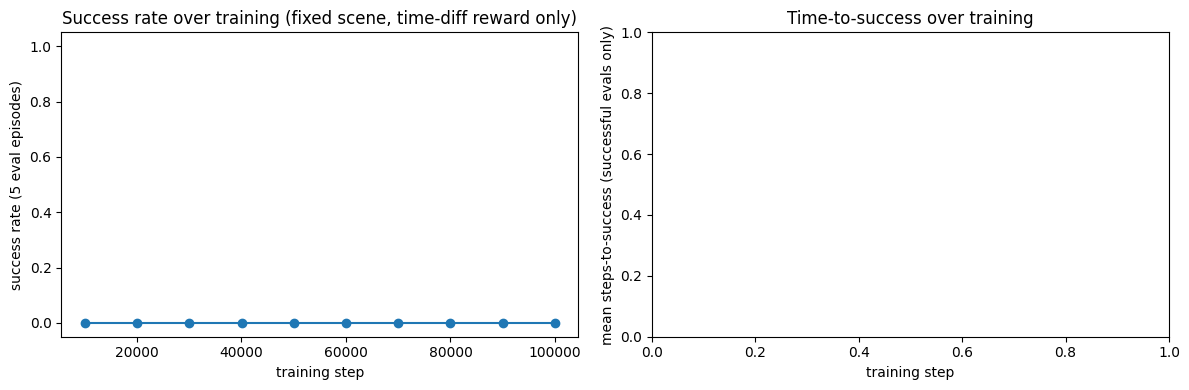

final success rate: 0.00
best success rate seen: 0.00 at step 10002


In [13]:
with open("./checkpoints/peg_insert_side_v6_timediff/eval_history.json") as f:
    history = json.load(f)

steps = [h["step"] for h in history]
success_rates = [h["success_rate"] for h in history]
mean_t2s = [h["mean_time_to_success"] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(steps, success_rates, marker="o")
axes[0].set_xlabel("training step"); axes[0].set_ylabel("success rate (5 eval episodes)")
axes[0].set_title("Success rate over training (fixed scene, time-diff reward only)")
axes[0].set_ylim(-0.05, 1.05)

valid = [(s, m) for s, m in zip(steps, mean_t2s) if m is not None]
if valid:
    vs, vm = zip(*valid)
    axes[1].plot(vs, vm, marker="o", color="tab:orange")
axes[1].set_xlabel("training step"); axes[1].set_ylabel("mean steps-to-success (successful evals only)")
axes[1].set_title("Time-to-success over training")

plt.tight_layout(); plt.show()

print(f"final success rate: {success_rates[-1]:.2f}")
print(f"best success rate seen: {max(success_rates):.2f} at step {steps[success_rates.index(max(success_rates))]}")

## 10. Final rollout video + prediction trace

Recorded on the same fixed scene, using the raw (un-stripped) env for rendering and for the time2success model, while feeding the trained policy the same peg-free observation it was trained on.

D:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")


saved validation_policy_v6_timediff.mp4 (500 frames)
success: False


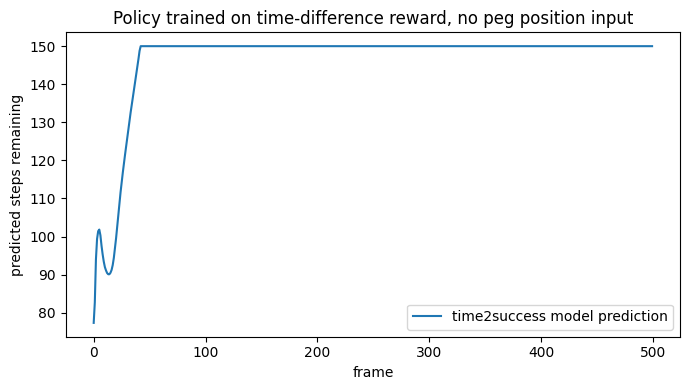

In [14]:
final_policy = SAC.load("./checkpoints/peg_insert_side_v6_timediff/policy_final")

record_env = make_fixed_scene_env(render_mode="rgb_array")
find_wrapper(record_env, "toggle_terminate_on_success").toggle_terminate_on_success(True)
keep_idx = np.array([i for i in range(39) if i not in PEG_POS_IDX])

obs, _ = record_env.reset()
frames, preds = [], []
success_step = None
for t in range(500):
    frames.append(record_env.render())
    preds.append(predict_t2s(obs))
    policy_obs = obs[keep_idx].astype(np.float32)
    action, _ = final_policy.predict(policy_obs, deterministic=True)
    obs, reward, terminated, truncated, info = record_env.step(action)
    if info.get(SUCCESS_KEY, 0) and success_step is None:
        success_step = t
    if terminated or truncated:
        break
record_env.close()

imageio.mimsave("validation_policy_v6_timediff.mp4", frames, fps=20)
print(f"saved validation_policy_v6_timediff.mp4 ({len(frames)} frames)")
print(f"success: {success_step is not None}" + (f" at frame {success_step}" if success_step is not None else ""))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(preds, label="time2success model prediction")
if success_step is not None:
    ax.axvline(success_step, color="green", linestyle=":", label="success")
ax.set_xlabel("frame"); ax.set_ylabel("predicted steps remaining")
ax.set_title("Policy trained on time-difference reward, no peg position input")
ax.legend()
plt.tight_layout(); plt.show()

## 12. Reward-mean diagnostic (from the TensorBoard log)

`eval/success_rate` only tells us the policy never solved the task from any eval checkpoint — it doesn't say why. `rollout/ep_rew_mean` (the shaped time-difference reward SAC was actually optimizing) fills that in.

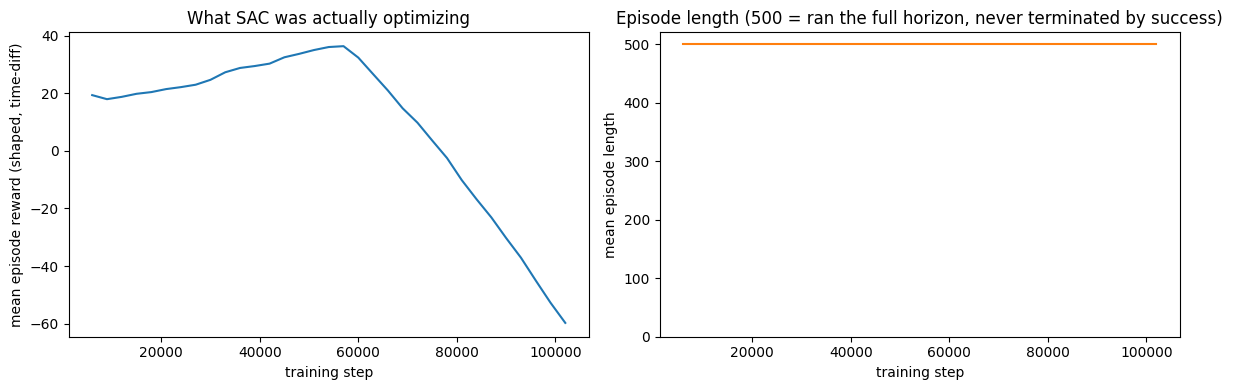

reward: starts at 19.3 (step 6000), peaks at 36.3 (step 57000), ends at -59.7 (step 102000)
actor loss magnitude: -13.2 -> -136.0 (growing magnitude here usually means the critic's value estimates are diverging)


In [1]:
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

ea = EventAccumulator("./tb_logs/peg_insert_side_v6_timediff/v6_timediff_run1_0")
ea.Reload()
rew = ea.Scalars("rollout/ep_rew_mean")
ep_len = ea.Scalars("rollout/ep_len_mean")
actor_loss = ea.Scalars("train/actor_loss")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot([p.step for p in rew], [p.value for p in rew])
axes[0].set_xlabel("training step"); axes[0].set_ylabel("mean episode reward (shaped, time-diff)")
axes[0].set_title("What SAC was actually optimizing")

axes[1].plot([p.step for p in ep_len], [p.value for p in ep_len], color="tab:orange")
axes[1].set_xlabel("training step"); axes[1].set_ylabel("mean episode length")
axes[1].set_title("Episode length (500 = ran the full horizon, never terminated by success)")
axes[1].set_ylim(0, 520)

plt.tight_layout(); plt.show()

peak = max(rew, key=lambda p: p.value)
print(f"reward: starts at {rew[0].value:.1f} (step {rew[0].step}), "
      f"peaks at {peak.value:.1f} (step {peak.step}), "
      f"ends at {rew[-1].value:.1f} (step {rew[-1].step})")
print(f"actor loss magnitude: {actor_loss[0].value:.1f} -> {actor_loss[-1].value:.1f} "
      f"(growing magnitude here usually means the critic's value estimates are diverging)")

### What this actually shows

The shaped reward climbed for the first ~55k steps (peak ~36 at step 57k),
then **collapsed to -60 by the end** — while `eval/success_rate` stayed at
0.00 the entire run and mean episode length stayed pinned at 500 (the
training env never terminates on success, so this alone doesn't distinguish
success from failure, but combined with the eval numbers it confirms no
episode ever finished early because it solved the task).

Read together, this is not "the signal was too weak to learn from" — SAC
clearly found *something* in the reward landscape to climb for a while. It's
closer to **reward hacking**: the undiscounted time-difference reward pays
out for any state-to-state transition the model rates as "improving,"
whether or not that improvement is actually monotonic toward the real goal.
Once the policy pushed into states further from the near-optimal manifold
the time2success model was trained on, its predictions likely stopped being
trustworthy (the exact off-distribution caveat flagged in Section 1),
letting the policy "profit" from transitions the model misjudged — and the
growing actor-loss magnitude alongside the reward collapse points to the
critic's value estimates diverging under that ungrounded signal, not a
graceful plateau.

**Conclusion for this run:** as implemented — undiscounted raw model
difference, no peg position in the observation, one fixed scene, 100k
steps — the arm did not learn the real insertion motion. That's a genuine
answer to the question this notebook asked, not an inconclusive one.

**What to try next, in order of how cheaply each isolates the cause:**

1. **Put peg position back in the observation** as a control run. If it
   still fails the same way, the bottleneck is the reward, not the missing
   peg location — cheapest way to rule that variable in or out.
2. **Switch to discounted potential-based shaping** (`gamma*phi(s') -
   phi(s)`, as in the older exploratory notebook) instead of raw
   differencing. It doesn't eliminate model-error exploitation, but it's
   provably policy-invariant under a *correct* potential, which raw
   differencing isn't — worth testing before concluding the whole idea is
   dead.
3. **Ground the signal periodically** — e.g. a real bonus on actual
   `info["success"]`, not just the model's opinion — so the policy can't
   drift arbitrarily far from ground truth before something corrects it.
4. **Train the time2success model on a wider state distribution** (not
   just near-optimal successful trajectories), so its predictions stay
   meaningful on the states an exploring policy actually visits early on.